In [1]:
import numpy as np
#from scipy.integrate import odeint
from scipy.integrate import solve_ivp as sl
import matplotlib.pyplot as plt
%matplotlib widget


#CASO DE N ROBOTS EN UN ESPACIO n-DIMENSIONAL

#todos los agentes siguen las mismas ecuaciones de trayectoria

#Definimos en una función las ecuaciones de la trayectoria 
np.random.seed(123)

def fun(w):
    f1 = 15*np.sin(2*w)
    f2 = 30*np.sin(w)*(np.sqrt(0.5*(1-0.5*(np.sin(w))**2)))
    f3 = 3+5*np.cos(2*w)
    #f1 = 10*np.sin(w)+20*np.sin(2*w)
    #f2 = 10*np.cos(w)-20*np.cos(2*w)
    #f3 = -40*np.sin(3*w)
    #f1 = (20 + 15*np.cos(2*w))*np.cos(w)
    #f2 = (20 + 15*np.cos(2*w))*np.sin(w)
    #f3 = 15 * np.sin(2*w)
    return np.array([f1, f2, f3])

#funciones phi
def phi(vec_pos):
    f = fun(vec_pos[-1])
    return vec_pos[:-1] - f

# calculamos la derivada de las ecuaciones de la trayectoria
def d_fun(w):
    #derivada central
    h = 1e-8 #paso
    df = (fun(w+h)-fun(w-h))/(2*h)
    return df

#matriz lapaciana de un grafo (los agentes están comunicados con los vecinos adyacentes)
def grafo_L(N):
    #N: nº de agentes 
    L = np.zeros([N,N])  
    
    # Llenar la diagonal con 2 
    np.fill_diagonal(L, 2)
    
    # Llenar las diagonales justo arriba y abajo de la diagonal principal con -1
    np.fill_diagonal(L[:, 1:], -1)
    np.fill_diagonal(L[1:, :], -1)
    
    # Llenar las esquinas con -1
    L[0, -1] = -1
    L[-1, 0] = -1
    
    return L

def vector_field(t,xi,k,n,N,ww,kc,L):
    #xi: posiciones de todos los agentes (vector columna con las 4 coordenadas )
    #t: tiempo
    #k: ganancias positivas
    #n: dimensiones 
    #N: nº de agentes 
    #L: matriz laplaciana de un grafo

    lista = np.arange(0,(n+1)*N+1,(n+1))
    k = k*N

    PHI = np.zeros(n*N) #lista vacía de funciones surface
    df = np.zeros(n*N)  #lista vacía de las derivadas 
    w = np.zeros(N)     #lista vacía para las coordenadas virtuales

    j = 0 
    for i in lista[:-1]: 
        x = xi[i:i+(n+1)]               #coordenada inicial + virtual de cada agente
        PHI[i-j:(i-j)+n] = phi(x)       #función surface 
        df[i-j:(i-j)+n] = d_fun(x[-1])  #derivada 
        w[j] = x[-1]                    #coordenadas virtuales 
        j += 1

    xi_eta = (-1)**n*df-k*PHI

    #sumatorio
    l = k*PHI*df
    # Convertir la matriz l en una matriz de n filas
    matriz_l = l.reshape((N, -1))
    #sumar a los largo del eje de las filas 
    suma = np.sum(matriz_l, axis=1)

    #función de coordinación 
    c = -L@np.transpose(w-ww)
    
    xi4 = (-1)**n+suma+kc*c

    #path-following guiding vector field 
    xi_eta = np.concatenate((xi_eta.reshape((N,n)),np.array([xi4]).T),axis=1)
    xi_eta = xi_eta.reshape((N*(n+1),-1)).T

    #print(PHI)

    return xi_eta[0]

#------------------------------------------------------------------------

#Parámetro de simulación 
n = 3           #dimensiones del espacio
N = 10           #nº de agentes 
ki =[1,1,2] #ganancias 

#coordenadas iniciales de los robots 
#pos = np.random.rand(N, n)*100 #filas: dimensiones
                           #columnas: nº de robots
pos = np.random.randint(-50, 51, size=(N, n))


#añadimos a la matriz de posiciones la coordenada virtual w 
w = np.ones((N,1)) #ejemplo: todos valen 1 

#concatenamos las dos matrices a lo largo de las filas 
Xi = np.concatenate((pos, w), axis=1)
Xi = Xi.reshape((N*(n+1),-1)).T #apilamos en un vector

#matriz lapaciana de un grafo 
L = grafo_L(N)

#parámetros para la componente de coordinación 
T = 2*np.pi #periodo 
Delta = T/N
kc = 300

ww = np.zeros(N)
for i in range(N):
    ww[i] = i*Delta

#resolvemos las ecuación diferencial 
#sol = odeint(vector_field,Xi[0],t,args=(ki,n,N,ww,kc,L))
sol = sl(vector_field, (0,10),Xi[0],method='LSODA',args=(ki,n,N,ww,kc,L),max_step=0.2) 

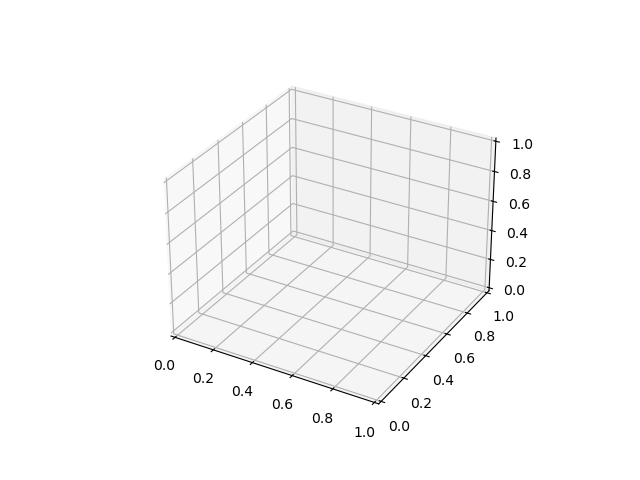

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, FFMpegWriter

# Configuración de la figura 3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Colores aleatorios para los robots puntuales
colors = [np.random.rand(3).tolist() for _ in range(N)]

# Función de actualización para la animación
def update(frame):
    ax.clear()  # Limpiar la figura en cada cuadro
    ax.set_xlim(-50, 50)
    ax.set_ylim(-50, 50)
    ax.set_zlim(-50, 50)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f"Robots Puntuales - Tiempo: {sol.t[frame]:.2f}s")
    
    # Dibujar las trayectorias y posiciones actuales
    for i, color in enumerate(colors):
        x = sol.y[i * (n + 1), :frame]        # Posiciones x
        y = sol.y[i * (n + 1) + 1, :frame]   # Posiciones y
        z = sol.y[i * (n + 1) + 2, :frame]   # Posiciones z
        ax.plot(x, y, z, color=color)  # Trayectoria del robot
        ax.scatter(x[-1], y[-1], z[-1], color=color, marker='o')  # Posición actual del robot

# Crear y guardar la animación
anim = FuncAnimation(fig, update, frames=len(sol.t), interval=100)

# Guardar como archivo de vídeo (requiere FFmpeg instalado)
writer = FFMpegWriter(fps=15, metadata={'title': 'Robots Puntuales'}, bitrate=1800)
anim.save("robots_puntuales.mp4", writer=writer)

print("¡Animación guardada en 'robots_puntuales.mp4'!")


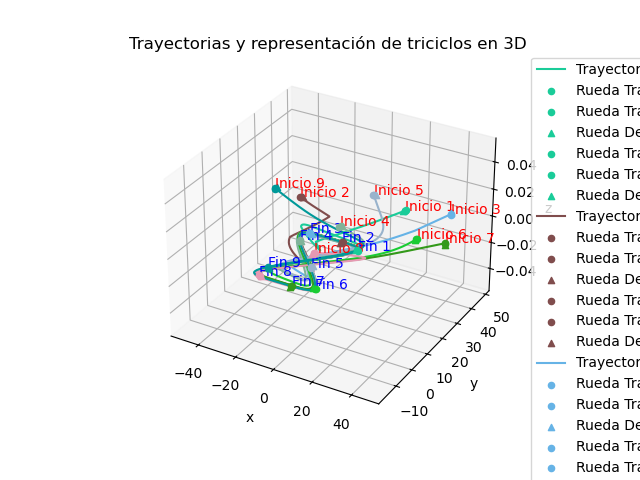

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Configuración de la figura 3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

lista = np.arange(0, 3*N+N, 3+1)  # Actualizamos para los triciclos (x, y, theta)
count = 1

# Función para visualizar el triciclo
def draw_tricycle(ax, x, y, theta, color):
    """
    Dibuja un triciclo representado por su posición y orientación.
    :param ax: Ejes de la figura.
    :param x, y, theta: Posición y orientación del triciclo.
    :param color: Color del triciclo.
    """
    # Dimensiones del triciclo
    L = 1  # Longitud entre rueda trasera y delantera
    W = 0.5  # Anchura del triciclo
    
    # Coordenadas de las ruedas traseras
    rear_left = [x - W/2 * np.cos(theta), y - W/2 * np.sin(theta)]
    rear_right = [x + W/2 * np.cos(theta), y + W/2 * np.sin(theta)]
    
    # Coordenadas de la rueda delantera
    front = [x + L * np.cos(theta), y + L * np.sin(theta)]
    
    # Dibujar el cuerpo del triciclo (línea entre las ruedas traseras y delanteras)
    ax.plot([rear_left[0], rear_right[0], front[0], rear_left[0]],
            [rear_left[1], rear_right[1], front[1], rear_left[1]], 
            [0, 0, 0, 0], color=color)  # Altura asumida 0 para simplificación
    
    # Dibujar las ruedas
    ax.scatter(rear_left[0], rear_left[1], 0, color=color, marker='o', label="Rueda Trasera Izq.")
    ax.scatter(rear_right[0], rear_right[1], 0, color=color, marker='o', label="Rueda Trasera Der.")
    ax.scatter(front[0], front[1], 0, color=color, marker='^', label="Rueda Delantera")

for i in lista[:-1]: 
    # Asignamos colores aleatorios
    r, g, b = np.round(np.random.rand(), 1), np.round(np.random.rand(), 1), np.round(np.random.rand(), 1)
    color = [r, g, b]
    
    # Extraemos las posiciones x, y, y la orientación theta desde el resultado de la simulación
    x = sol.y[i, :]         # Posición x
    y = sol.y[i + 1, :]     # Posición y
    theta = sol.y[i + 2, :] # Orientación theta
    
    # Graficamos la trayectoria del centro del triciclo
    ax.plot(x, y, np.zeros_like(x), color=color, label=f"Trayectoria Robot {count}")
    
    # Visualizamos el triciclo inicial y final
    draw_tricycle(ax, x[0], y[0], theta[0], color)
    draw_tricycle(ax, x[-1], y[-1], theta[-1], color)
    
    # Etiquetamos el inicio y el final del robot
    ax.text(x[0], y[0], 0, f"Inicio {count}", color='red')
    ax.text(x[-1], y[-1], 0, f"Fin {count}", color='blue')
    
    count += 1

# Etiquetas de los ejes
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Trayectorias y representación de triciclos en 3D')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()


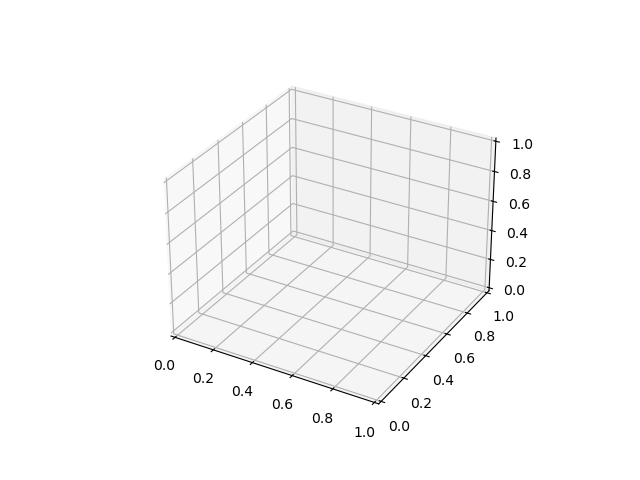

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, FFMpegWriter

# Función para dibujar un triciclo
def draw_tricycle(ax, x, y, theta, color, scale=1):
    L = 1 * scale  # Longitud entre ruedas traseras y delantera
    W = 0.5 * scale  # Anchura del triciclo

    # Coordenadas de las ruedas traseras
    rear_left = [x - W / 2 * np.cos(theta), y - W / 2 * np.sin(theta)]
    rear_right = [x + W / 2 * np.cos(theta), y + W / 2 * np.sin(theta)]
    # Coordenadas de la rueda delantera
    front = [x + L * np.cos(theta), y + L * np.sin(theta)]

    # Dibujar el cuerpo del triciclo
    ax.plot([rear_left[0], rear_right[0], front[0], rear_left[0]],
            [rear_left[1], rear_right[1], front[1], rear_left[1]],
            [0, 0, 0, 0], color=color)  # Altura asumida en 0

    # Dibujar las ruedas
    ax.scatter(rear_left[0], rear_left[1], 0, color=color, marker='o')  # Trasera izquierda
    ax.scatter(rear_right[0], rear_right[1], 0, color=color, marker='o')  # Trasera derecha
    ax.scatter(front[0], front[1], 0, color=color, marker='^')  # Delantera

# Configuración de la figura 3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Colores aleatorios para los triciclos
colors = [np.random.rand(3).tolist() for _ in range(N)]

# Función de actualización para la animación
def update(frame):
    ax.clear()
    ax.set_xlim(-50, 50)
    ax.set_ylim(-50, 50)
    ax.set_zlim(0, 1)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f"Triciclos - Tiempo: {sol.t[frame]:.2f}s")
    
    # Dibujar los triciclos
    for i, color in enumerate(colors):
        x = sol.y[i * 3, frame]        # Posición x
        y = sol.y[i * 3 + 1, frame]   # Posición y
        theta = sol.y[i * 3 + 2, frame] # Orientación theta
        draw_tricycle(ax, x, y, theta, color)

# Crear y guardar la animación
anim = FuncAnimation(fig, update, frames=len(sol.t), interval=100)

# Guardar como archivo de vídeo
writer = FFMpegWriter(fps=15, metadata={'title': 'Triciclos'}, bitrate=1800)
anim.save("triciclos.mp4", writer=writer)

print("¡Animación guardada en 'triciclos.mp4'!")
